# graphtope — iterative development notebook

**Carrier:** `topologicpy.Graph` (sole carrier). **Workflow:** develop here, extract stabilized
code into `graphtope/*.py`. **Scope:** M0 spike → M5 (reproduce the figure-5 Dom Narkomfin graph).

See `Topologic_Graph_Grammar_Spec.md` (spec), `CLAUDE.md` (carrier gotchas), and
`docs/Topologic_Carrier_Contribution_Briefing.md` (what to upstream to TopologicPy).


In [1]:
import topologicpy, networkx, graphtope
from graphtope import StateGraph, alphabet as A, serialize
print("topologicpy", topologicpy.__version__, "| networkx", networkx.__version__,
      "| graphtope", graphtope.__version__)

topologicpy 0.9.43 | networkx 3.6.1 | graphtope 0.1.0


## M0 — API spike (findings, already folded into the briefing note)

Measured against TopologicPy 0.9.43:

| Question | Result | Consequence |
|---|---|---|
| Parallel edges? | **deduped** (`Size==1`) | no multigraph at Stage 1; symmetry via `bidirectional` flag |
| Direction? | opt-in `directed=True`; `AdjacentVertices` ignores it | wrap traversal, always pass direction |
| Mutation? | **in-place**; Vertex identity **not** preserved | address by `id` via `VertexByKeyValue` |
| Edge dicts? | dropped unless `transferEdgeDictionaries=True`; bools→int; ontology keys injected | handled in `_topo.py` |
| Subgraph match? | vertices only, no edge/direction matcher | implement matcher in `rules.py` (M4) |

These are encoded as workarounds in `graphtope._topo` and `graphtope.model`.

## M1 — carrier + invariants

### Axiom A₀ (§7.0): two isolated generic blocks

In [2]:
G = StateGraph.axiom()
print(G)
print("nodes:", G.nodes())
print("b1 label/attrs:", G.node_label("b1"), G.node_attrs("b1"))
assert G.is_well_formed()

<StateGraph |N|=2 |E|=0 well_formed=True>
nodes: ['b1', 'b2']
b1 label/attrs: generic {'block': 'residential'}


### Build a small typed/directed graph by hand and validate (§2.2)

In [3]:
g = StateGraph()
g.add_node(A.GENERIC,   id="g1")
g.add_node(A.CORRIDOR,  id="c1", level=1)
g.add_node(A.STAIRCASE, id="s1")
g.add_edge("g1", "c1", A.H)            # horizontal adjacency (bidirectional)
g.add_edge("c1", "s1", A.V)            # vertical: c1 above s1 (one-way)

print(g)
print("edges:")
for e in g.edges():
    print("  ", e)
print("well-formedness errors:", g.well_formedness_errors())
print("H edge bidirectional:", g.edge("g1","c1")["bidirectional"],
      "| V edge bidirectional:", g.edge("c1","s1")["bidirectional"])
print("degrees  c1: out", g.out_degree("c1"), "in", g.in_degree("c1"))

<StateGraph |N|=3 |E|=2 well_formed=True>
edges:
   {'src': 'g1', 'tgt': 'c1', 'type': 'adjacency', 'orientation': 'H', 'bidirectional': True, 'weight': 1.0, 'attrs': {}}
   {'src': 'c1', 'tgt': 's1', 'type': 'adjacency', 'orientation': 'V', 'bidirectional': False, 'weight': 1.0, 'attrs': {}}
well-formedness errors: []
H edge bidirectional: True | V edge bidirectional: False
degrees  c1: out 1 in 1


### Invariants reject ill-formed inputs (§2.2)

In [4]:
for desc, thunk in [
    ("unknown label", lambda: g.add_node("not_a_label", id="x")),
    ("self-loop",     lambda: g.add_edge("g1", "g1", A.H)),
    ("bad orientation", lambda: g.add_edge("g1", "s1", "diagonal")),
    ("duplicate id",  lambda: g.add_node(id="g1")),
]:
    try:
        thunk(); print("NO ERROR (unexpected):", desc)
    except ValueError as ex:
        print("rejected:", desc, "->", ex)

rejected: unknown label -> unknown node label 'not_a_label'; Σ=['corridor', 'entrance', 'generic', 'l_section', 'staircase', 'u_section']
rejected: self-loop -> self-loops are not allowed (§2.2 inv-4)
rejected: bad orientation -> bad orientation 'diagonal'; Θ-orient=['H', 'V']
rejected: duplicate id -> duplicate node id 'g1'


### JSON round-trip (§10.1)

In [5]:
data = serialize.to_dict(g)
g2 = serialize.from_dict(data)
assert serialize.to_dict(g2) == data
import json; print(json.dumps(data, indent=2))

{
  "directed": true,
  "multigraph": true,
  "nodes": [
    {
      "id": "c1",
      "label": "corridor",
      "attrs": {
        "level": 1
      }
    },
    {
      "id": "g1",
      "label": "generic",
      "attrs": {}
    },
    {
      "id": "s1",
      "label": "staircase",
      "attrs": {}
    }
  ],
  "edges": [
    {
      "src": "c1",
      "tgt": "s1",
      "type": "adjacency",
      "orientation": "V",
      "bidirectional": false,
      "weight": 1.0,
      "attrs": {}
    },
    {
      "src": "g1",
      "tgt": "c1",
      "type": "adjacency",
      "orientation": "H",
      "bidirectional": true,
      "weight": 1.0,
      "attrs": {}
    }
  ]
}


### Visualise (topologic renderer; coordinates are layout only)

`G.show()` opens TopologicPy's Plotly viewer; `G.to_networkx()` is the escape-hatch view.

In [6]:
nxg = g.to_networkx()
print("networkx view:", nxg.number_of_nodes(), "nodes,", nxg.number_of_edges(), "edges")
g.show()                 # uncomment for the interactive Plotly graph

networkx view: 3 nodes, 2 edges


## M2 — atomic basis A1–A7 (spec §4)

Seven reversible primitives. Each `op.apply(sg)` checks its precondition, performs
the effect, and **returns its inverse op** (capturing the pre-state the inverse needs).
So `inverse(op) ∘ op == id` — the reversibility at the heart of D-I / D-IV.

In [7]:
from graphtope.atomic import (AddNode, DelNode, AddEdge, DelEdge,
                               Relabel, Reweight, ReverseEdge)
from graphtope import serialize

g = StateGraph()
g.add_node(A.GENERIC, id="a"); g.add_node(A.GENERIC, id="b")
snapshot = serialize.to_dict(g)

op  = AddEdge("a", "b", A.V, weight=2.0)     # A3: a above b
inv = op.apply(g)                             # mutates g, returns the inverse (DelEdge)
print("after A3 :", g, "| inverse is", type(inv).__name__)
inv.apply(g)                                  # A4 undoes it
print("restored == snapshot:", serialize.to_dict(g) == snapshot)

after A3 : <StateGraph |N|=2 |E|=1 well_formed=True> | inverse is DelEdge
restored == snapshot: True


### Each atomic and its inverse, end to end

In [8]:
def reversible(build, op):
    g = build()
    before = serialize.to_dict(g)
    inv = op.apply(g)
    inv.apply(g)
    return serialize.to_dict(g) == before, type(op).__name__, "->", type(inv).__name__

def two_nodes():
    g = StateGraph(); g.add_node(A.GENERIC, id="a"); g.add_node(A.GENERIC, id="b"); return g
def two_nodes_edge():
    g = two_nodes(); g.add_edge("a", "b", A.H, weight=1.0); return g
def one_node():
    g = StateGraph(); g.add_node(A.STAIRCASE, id="s", level=2); return g

for ok, *what in [
    reversible(StateGraph, AddNode(A.CORRIDOR, {"level": 1})),  # A1 / A2
    reversible(one_node,   DelNode("s")),                       # A2 / A1
    reversible(two_nodes,  AddEdge("a", "b", A.V)),             # A3 / A4
    reversible(two_nodes_edge, DelEdge("a", "b")),              # A4 / A3
    reversible(one_node,   Relabel("s", A.CORRIDOR)),           # A5 / A5
    reversible(two_nodes_edge, Reweight("a", "b", 9.0)),        # A6 / A6
    reversible(two_nodes_edge, ReverseEdge("a", "b")),          # A7 / A7
]:
    print(f"{'OK ' if ok else 'FAIL'}  {what[0]:<11} inverse {what[2]}")

OK   AddNode     inverse DelNode
OK   DelNode     inverse AddNode
OK   AddEdge     inverse DelEdge
OK   DelEdge     inverse AddEdge
OK   Relabel     inverse Relabel
OK   Reweight    inverse Reweight
OK   ReverseEdge inverse ReverseEdge


### Property: `inverse(op) ∘ op == id` on random well-formed graphs

A quick in-notebook version of `tests/test_atomic.py::test_reversibility_property`.

In [9]:
import random
def random_graph(rng, n=6):
    g = StateGraph(); ids = [f"n{i}" for i in range(n)]
    for nid in ids:
        g.add_node(rng.choice(list(A.NODE_LABELS)), id=nid, level=rng.randint(0, 2))
    seen = set()
    for _ in range(n):
        a, b = rng.sample(ids, 2)
        if (a, b) in seen or (b, a) in seen: continue
        g.add_edge(a, b, rng.choice([A.H, A.V]), weight=round(rng.uniform(.5, 3), 2))
        seen.add((a, b))
    return g

rng = random.Random(0); fails = 0
for _ in range(200):
    g = random_graph(rng); before = serialize.to_dict(g)
    edges = [(e["src"], e["tgt"]) for e in g.edges()]
    if not edges: continue
    a, b = rng.choice(edges)
    inv = ReverseEdge(a, b).apply(g); inv.apply(g)
    fails += serialize.to_dict(g) != before
print("reverse-edge round-trips:", "ALL OK" if fails == 0 else f"{fails} FAILED")

reverse-edge round-trips: ALL OK


## M3 — core composite operations (spec §5)

The six generic verbs as recipes over the atomics. Each composite returns an
`OpSequence` (the reversed atomic inverses), so `inverse(op) ∘ op == id` exactly —
this is the "merge record / recovered π" of §5.1, for free.

In [10]:
from graphtope.composite import (Split, Merge, Divide, Union, Difference,
                                  Mirror, Transform, AttachPendant)

def ctx():
    g = StateGraph()
    g.add_node(A.GENERIC, id="m", area=10)
    g.add_node(A.CORRIDOR, id="L"); g.add_node(A.STAIRCASE, id="R")
    g.add_edge("L", "m", A.H, weight=2.0)
    g.add_edge("m", "R", A.H, weight=3.0)
    return g

g = ctx(); before = serialize.to_dict(g)
sp = Split("m", A.H)                       # divide m into two adjacent spaces
inv = sp.apply(g)
print("after SPLIT:", g, "children:", sp.children)
inv.apply(g)
print("inverse(SPLIT) ∘ SPLIT == id:", serialize.to_dict(g) == before)

after SPLIT: <StateGraph |N|=4 |E|=3 well_formed=True> children: ('n0', 'n1')
inverse(SPLIT) ∘ SPLIT == id: True


### SPLIT then MERGE returns to the start

In [11]:
g = ctx(); before = serialize.to_dict(g)
sp = Split("m", A.H); sp.apply(g)
c1, c2 = sp.children
Merge(c1, c2, result_id="m", result_label=A.GENERIC, result_attrs={"area": 10}).apply(g)
print("MERGE ∘ SPLIT == id (exact, with recovered id):", serialize.to_dict(g) == before)

MERGE ∘ SPLIT == id (exact, with recovered id): True


### MERGE coalesces a shared neighbour under ξ = max (and still inverts)

In [12]:
g = StateGraph()
g.add_node(A.GENERIC, id="a"); g.add_node(A.GENERIC, id="b"); g.add_node(A.CORRIDOR, id="x")
g.add_edge("a", "b", A.H); g.add_edge("a", "x", A.H, weight=2.0); g.add_edge("b", "x", A.H, weight=5.0)
before = serialize.to_dict(g)
inv = Merge("a", "b", result_id="ab").apply(g)
print("coalesced a/b → x weight (max 2,5):", g.edge("ab", "x")["weight"], "| edges:", g.size())
inv.apply(g)
print("un-coalesced exactly:", serialize.to_dict(g) == before)

coalesced a/b → x weight (max 2,5): 5.0 | edges: 1
un-coalesced exactly: True


### DIVIDE(k) = (k−1) chained SPLITs → a row of k cells (the apartment spine)

In [13]:
g = StateGraph(); g.add_node(A.GENERIC, id="blk")
d = Divide("blk", 4, A.H); d.apply(g)
print("cells:", d.children, "| nodes:", g.order(), "edges:", g.size())
for e in g.edges():
    print("   ", e["src"], "—", e["tgt"])

cells: ['n0', 'n2', 'n4', 'n5'] | nodes: 4 edges: 3
    n0 — n2
    n2 — n4
    n4 — n5


### MIRROR — reflect a wing across a seam (§5.3, the paper's open operation)

In [14]:
g = StateGraph()
g.add_node(A.CORRIDOR, id="c"); g.add_node(A.GENERIC, id="g1")
g.add_edge("c", "g1", A.H)
m = Mirror(["c", "g1"], seam=["c"]); m.apply(g)
print("after MIRROR:", g, "| copies:", m.copies)
print("seam stitch c — c':", g.has_edge("c", m.copies["c"]))

after MIRROR: <StateGraph |N|=4 |E|=3 well_formed=True> | copies: {'c': 'n0', 'g1': 'n1'}
seam stitch c — c': True


## M4 — DPO productions, matcher & NACs (spec §6)

A production is a span `L ⊇ K ⊆ R`. The matcher is a typed-attributed **directed**
subgraph monomorphism (label/subtype, edge type+orientation, direction). Bidirectional
H-adjacency matches either way; one-way edges (V, entrance) are strict. NACs block
over-generation. Application is built from atomics, so it stays reversible.

In [15]:
from graphtope.rules import Pattern, PNode, PEdge, Production, match_pattern, add_node_production

g = StateGraph()
g.add_node(A.GENERIC, id="g1"); g.add_node(A.CORRIDOR, id="c1"); g.add_node(A.GENERIC, id="g2")
g.add_edge("g1", "c1", A.H); g.add_edge("c1", "g2", A.H)

# match a generic — corridor — generic triad (any direction on the H edges)
pat = Pattern([PNode("a", label=A.GENERIC), PNode("c", label=A.CORRIDOR), PNode("b", label=A.GENERIC)],
              [PEdge("a", "c", orientation=A.H), PEdge("c", "b", orientation=A.H)])
ms = match_pattern(pat, g)
print("matches of  g—c—g :")
for m in ms: print("   ", m)

matches of  g—c—g :
    {'a': 'g1', 'c': 'c1', 'b': 'g2'}
    {'a': 'g2', 'c': 'c1', 'b': 'g1'}


### A named production with a NAC: add an entrance, at most one per block (P5-like)

In [16]:
x = PNode("x", label=A.CORRIDOR); e = PNode("e", label=A.ENTRANCE)
nac = Pattern([PNode("x"), PNode("en", label=A.ENTRANCE)], [PEdge("en", "x", orientation=A.H)])
P5 = Production(name="P5", lhs=Pattern([x]), interface={"x"},
                rhs=Pattern([x, e], [PEdge("e", "x", orientation=A.H, bidirectional=False)]),
                nacs=[nac], instantiates="+N(entrance)+UNION(one-way)")

g = StateGraph(); g.add_node(A.CORRIDOR, id="c")
print("valid matches before any entrance:", len(P5.matches(g)))
inv, m = P5.apply_first(g)
ent = [n for n in g.nodes() if g.node_label(n) == A.ENTRANCE][0]
print("added entrance:", ent, "| one-way edge e→c:", g.edge(ent, "c"))
print("valid matches now (NAC blocks a 2nd):", len(P5.matches(g)))
inv.apply(g); print("inverted; back to:", g)

valid matches before any entrance: 1
added entrance: n0 | one-way edge e→c: {'src': 'n0', 'tgt': 'c', 'type': 'adjacency', 'orientation': 'H', 'bidirectional': False, 'weight': 1.0, 'attrs': {}}
valid matches now (NAC blocks a 2nd): 0
inverted; back to: <StateGraph |N|=1 |E|=0 well_formed=True>


## M5 — the Dom Narkomfin grammar & the §8 derivation (spec §7–§8)

P1–P8 as `Production` instances; the engine runs `A₀ →* G_DNF`, and the result is
checked (up to typed isomorphism) against an independently hand-built figure-5 graph.
Because every rule is reversible, the **reverse derivation returns the axiom**.

In [17]:
from graphtope import grammar_dnf as dnf
from graphtope.engine import Derivation

d = Derivation(StateGraph.axiom())          # A₀: b1, b2 (two generic blocks)
dnf.derive(d)                                # apply P1–P8 per §8
G = d.sg
print("G_DNF:", G, "| fully refined?", G.is_fully_refined())
print("steps:", [s['rule'] for s in d.trace()])

G_DNF: <StateGraph |N|=18 |E|=18 well_formed=True> | fully refined? False
steps: ['P1', 'P1', 'P3', 'P3', 'P4', 'P4', 'P5', 'P6', 'P7', 'P2', 'P4', 'P5', 'P8']


### Recovery: the derivation reproduces the hand-built figure-5 graph

In [18]:
import networkx as nx
def typed_nx(sg):
    Gx = nx.DiGraph()
    for n in sg.nodes():
        Gx.add_node(n, label=sg.node_label(n), subtype=sg.node_attrs(n).get("subtype"))
    for e in sg.edges():
        a = {"orientation": e["orientation"], "type": e["type"]}
        Gx.add_edge(e["src"], e["tgt"], **a)
        if e["bidirectional"]: Gx.add_edge(e["tgt"], e["src"], **a)
    return Gx
def typed_iso(a, b):
    return nx.is_isomorphic(typed_nx(a), typed_nx(b),
                            node_match=lambda x, y: x == y, edge_match=lambda x, y: x == y)

print("A₀ →* G_DNF  ≅  hand-built figure-5 graph:", typed_iso(G, dnf.hand_built_dnf()))

from collections import Counter
print("typed composition:", dict(Counter(G.node_label(n) for n in G.nodes())))

A₀ →* G_DNF  ≅  hand-built figure-5 graph: True
typed composition: {'generic': 8, 'corridor': 2, 'u_section': 2, 'entrance': 2, 'staircase': 3, 'l_section': 1}


### The grammar runs both ways — reverse derivation returns A₀

In [19]:
d.invert()
print("after inverting the whole derivation:", d.sg)
print("== A₀ ?", serialize.to_dict(d.sg) == serialize.to_dict(StateGraph.axiom()))

after inverting the whole derivation: <StateGraph |N|=2 |E|=0 well_formed=True>
== A₀ ? True


### Visualise the derived DNF graph

`G.show()` opens the TopologicPy Plotly view (coordinates are layout only).
The graph is two components — residential + condenser — joined later by the
inter-block **bridge** (M7, §7.6.3).

In [20]:
G2, _ = dnf.derive_dnf()
print("components (residential + condenser):",
      nx.number_weakly_connected_components(typed_nx(G2)))
# G2.show()       # uncomment for the interactive 3-D/Plotly view

components (residential + condenser): 2


## Visualising the grammar step by step

Stage 1 has no geometry yet, so we draw the **typed adjacency graph** — the figure-5
view. Each node is a glyph hinting its shape-type (`generic` box, `corridor` wide bar,
`staircase` tall bar, `u_section` **U**, `l_section` **L**, `entrance` triangle),
coloured by the §3.1 legend; edges are H (solid) / V (dashed), with an arrowhead for
one-way relations. `record_frames` snapshots the graph after every production, and a
shared layout keeps nodes from jumping so you can watch the building grow.

captured 14 frames: ['A₀ axiom', 'P1', 'P1', 'P3', 'P3', 'P4', 'P4', 'P5', 'P6', 'P7', 'P2', 'P4', 'P5', 'P8']


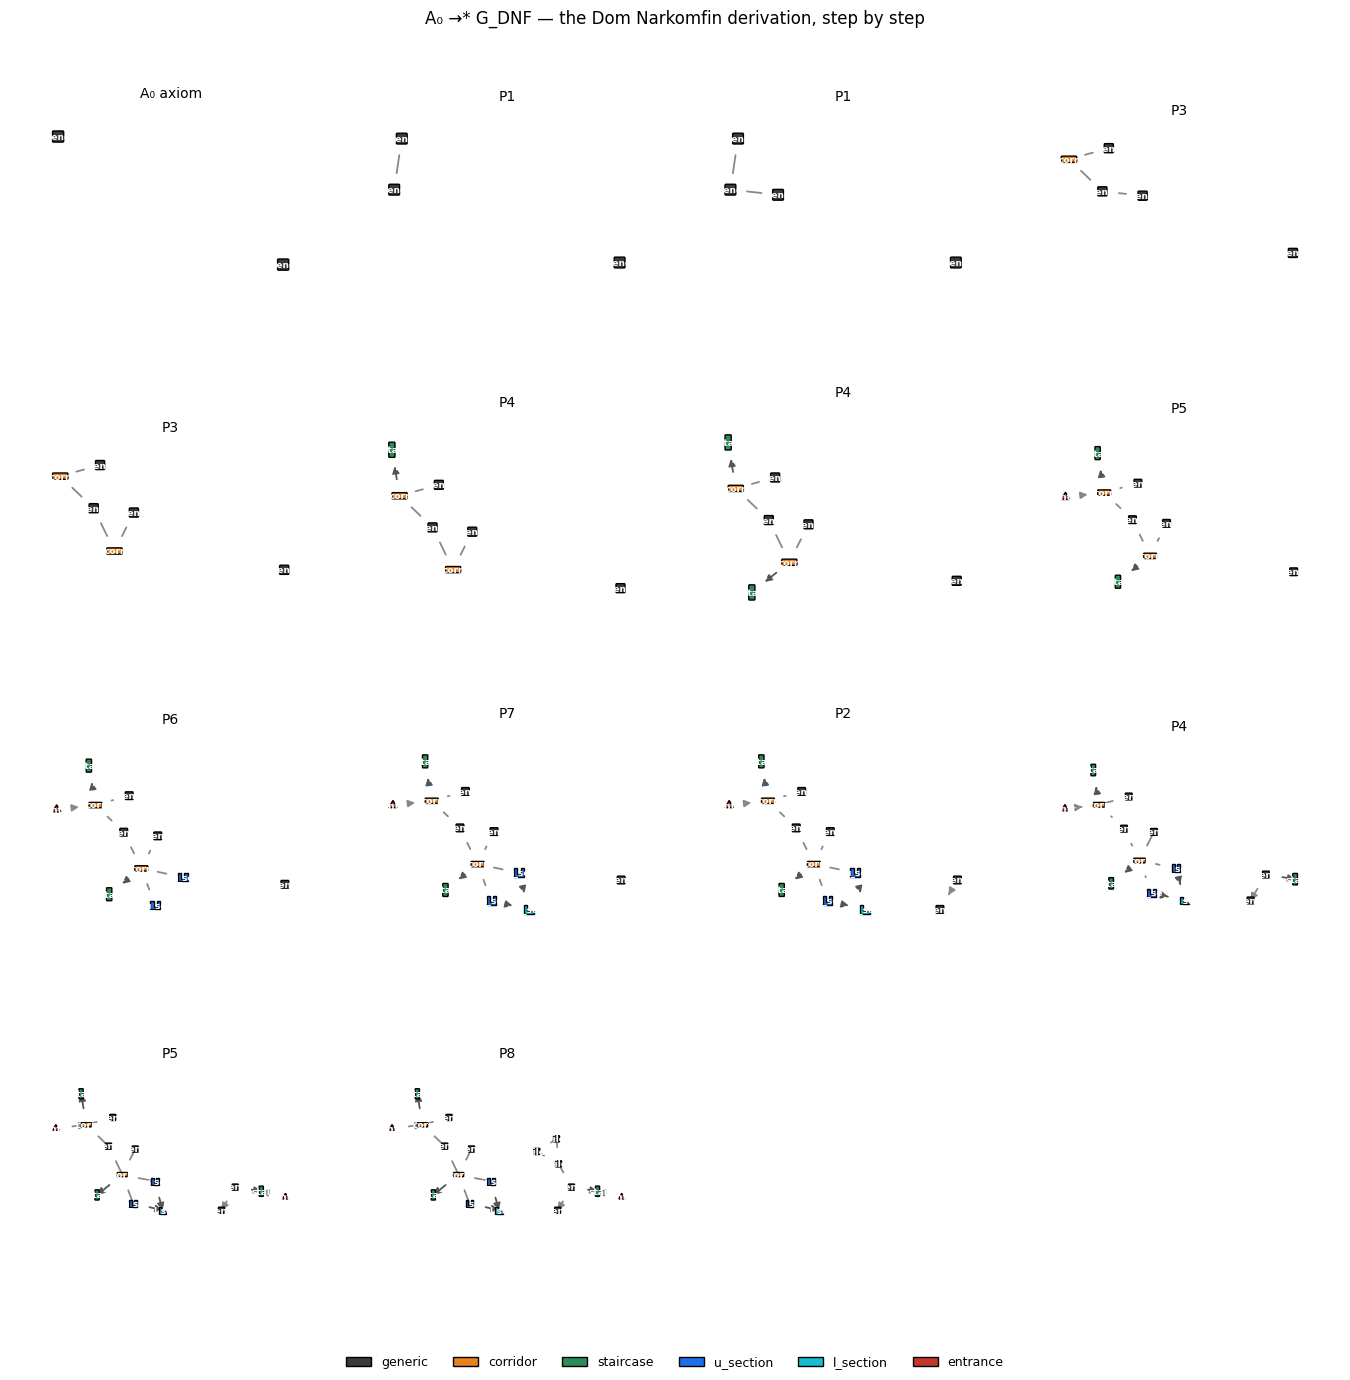

In [21]:
%matplotlib inline
from graphtope import topoview

# capture the axiom + a snapshot after each production of the §8 derivation
frames, d = topoview.record_frames(StateGraph.axiom(), dnf.derive)
print("captured", len(frames), "frames:", [t for t, _ in frames])

fig = topoview.draw_grid(frames, ncols=4, panel=3.4)   # residential (left) + condenser (right)
fig.suptitle("A₀ →* G_DNF — the Dom Narkomfin derivation, step by step", y=1.005)
None

### A single state, larger — the final typed graph

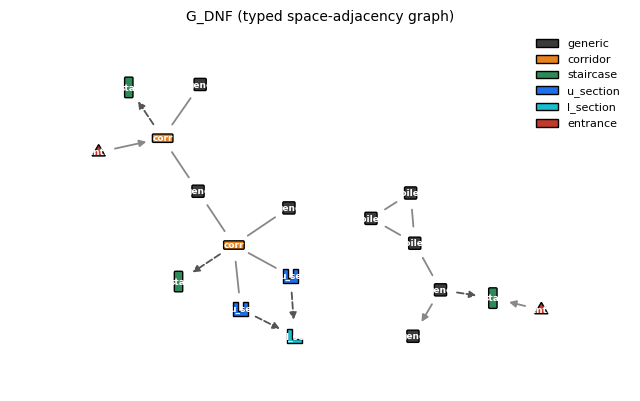

In [22]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 6))
topoview.draw(d.sg, ax=ax, title="G_DNF (typed space-adjacency graph)")
ax.legend(handles=topoview.legend_handles(), loc="upper right", fontsize=8, frameon=False)
None

### Watching a sub-grammar refine a unit (M7)

The same recorder works for any op sequence — here, refining the two `u_section`
non-terminals into their lower/upper/stair interiors.

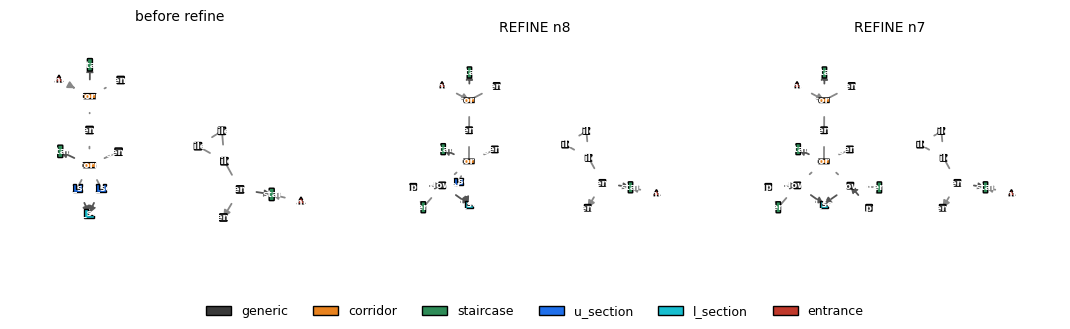

In [23]:
from graphtope.hierarchy import Refine, u_section_unit
from graphtope.engine import Derivation

g0, _ = dnf.derive_dnf()
us = [n for n in g0.nodes() if g0.node_label(n) == A.U_SECTION]
rframes = [("before refine", serialize.to_dict(g0))]
for n in us:
    Refine(n, u_section_unit()).apply(g0)
    rframes.append((f"REFINE {n}", serialize.to_dict(g0)))
fig = topoview.draw_grid(rframes, ncols=3, panel=3.6)
None

## M6 — derivation trace: record / replay / invert + the τ shape stub (§9, §10.2)

The trace is JSON-serializable; replaying it on a fresh axiom reproduces the graph
(deterministic ids), and the rebuilt derivation inverts back to A₀. τ maps labels to
shape types and adjacency edges to the shared faces Stage 2 will realise — no geometry.

In [24]:
from graphtope.engine import Derivation, replay
from graphtope import grammar_dnf as dnf, shape_iface

d = Derivation(StateGraph.axiom()); dnf.derive(d)
trace = d.trace()
print("trace steps:", [s['rule'] for s in trace])

d2 = replay(trace, dnf.PRODUCTIONS)                  # replay on a fresh axiom
print("replay == forward run:", serialize.to_dict(d2.sg) == serialize.to_dict(d.sg))
d2.invert()
print("replay then invert == A₀:", serialize.to_dict(d2.sg) == serialize.to_dict(StateGraph.axiom()))

trace steps: ['P1', 'P1', 'P3', 'P3', 'P4', 'P4', 'P5', 'P6', 'P7', 'P2', 'P4', 'P5', 'P8']
replay == forward run: True
replay then invert == A₀: True


In [25]:
# τ : Σ → ShapeType, and adjacency → shared face (Stage-2 boundary)
g, _ = dnf.derive_dnf()
from collections import Counter
print("node shape types:", dict(Counter(shape_iface.realise_node_types(g).values())))
faces = Counter(f['face'] for f in shape_iface.realise_edge_faces(g))
print("edge → shared face:", dict(faces))

node shape types: {'elongated_parallelepiped': 2, 'parallelepiped': 8, 'ground_floor_opening': 2, 'vertical_parallelepiped': 3, 'u_profile_solid': 2, 'l_profile_solid': 1}
edge → shared face: {'shared_horizontal_face_slab': 5, 'shared_vertical_face_wall': 13}


## M7 — hierarchy (REFINE / ABSTRACT) and the inter-block BRIDGE (§7.6)

Non-terminals (`u_section`, `l_section`) refine via a section sub-grammar; blocks
are derived independently and joined by a bridge once complete.

In [26]:
from graphtope.hierarchy import Refine, u_section_unit, l_section_unit

g, _ = dnf.derive_dnf()
print("before refinement, fully refined?", g.is_fully_refined())
# refine every non-terminal into its sub-grammar interior
for n in [n for n in g.nodes() if g.node_label(n) == A.U_SECTION]:
    Refine(n, u_section_unit()).apply(g)
for n in [n for n in g.nodes() if g.node_label(n) == A.L_SECTION]:
    Refine(n, l_section_unit()).apply(g)
print("after refinement, fully refined?", g.is_fully_refined(), "| nodes:", g.order())

before refinement, fully refined? False


after refinement, fully refined? True | nodes: 23


In [27]:
from graphtope.compose import disjoint_union, Bridge
import networkx as nx
def components(sg):
    G = nx.DiGraph(); G.add_nodes_from(sg.nodes())
    for e in sg.edges(): G.add_edge(e['src'], e['tgt'])
    return nx.number_weakly_connected_components(G)

# derive the two blocks independently, then compose + bridge
gr = StateGraph(); gr.add_node(A.GENERIC, id="b1", block="residential")
dnf.derive_residential(Derivation(gr), "b1")
gc = StateGraph(); gc.add_node(A.GENERIC, id="b2", block="condenser")
dnf.derive_condenser(Derivation(gc), "b2")

combined, ma, mb = disjoint_union(gr, gc)
print("combined components (pre-bridge):", components(combined))
Bridge(ma["b1"], mb["b2"], connector="corridor").apply(combined)
print("combined components (post-bridge):", components(combined), "| nodes:", combined.order())

combined components (pre-bridge):

 2
combined components (post-bridge): 1 | nodes: 19


## Stage 1 complete (M1–M7)

Carrier + invariants → reversible atomics → core verbs → DPO rules/matcher/NACs →
the Dom Narkomfin grammar reproducing figure 5 and running backwards →
trace replay/invert + the τ shape boundary → sub-grammar refinement + inter-block
bridge. Stage 2 (geometry via Topologic Cells) swaps the matcher for `IsSimilar`
and adds the realisation map at the τ boundary — without changing the rule structure.

# Stage 2 — attaching geometry (spec §9)

The single rule Stage 1 hands forward is τ : Σ → ShapeType. Stage 2 realises each
node as a Topologic **Cell** and each adjacency as a **shared face** (H ⇒ wall,
V ⇒ slab + stacking), assembles a **CellComplex**, then extracts the adjacency
*back* with `Graph.ByTopology` — the round-trip that verifies the geometry encodes
the Stage-1 graph. **The rule structure does not change**: we only add the
realisation map and swap the matcher for a geometric predicate.

In [28]:
from graphtope import realise
G, _ = dnf.derive_dnf()

rep = realise.roundtrip_report(G)
print(f"cells realised         : {rep['cells']}")
print(f"adjacencies intended   : {len(rep['realised']) + len(rep['unrealised'])}")
print(f"  realised as faces     : {len(rep['realised'])}")
print(f"  not grid-embeddable   : {len(rep['unrealised'])}")
print(f"round-trip complete?   : {rep['complete']}  (every realised adjacency is a shared face)")
print(f"extracted graph (order/size): {rep['graph_order']} / {rep['graph_size']}")
print("non-embeddable motifs  :",
      sorted((G.node_label(a), G.node_label(b)) for a, b in (tuple(s) for s in rep['unrealised'])))

cells realised         : 18
adjacencies intended   : 18
  realised as faces     : 17
  not grid-embeddable   : 1
round-trip complete?   : True  (every realised adjacency is a shared face)
extracted graph (order/size): 18 / 19
non-embeddable motifs  : [('l_section', 'u_section')]


The two misses are *architecturally* meaningful and genuinely non-grid-embeddable:
the condenser toilet **triad** (a 3-cycle) and the **u_section ↔ l_section interlock**
(one L below two U's — the Narkomfin split-level itself). Everything else round-trips.

### The realised 3-D massing — cells are spaces, shared faces are adjacencies

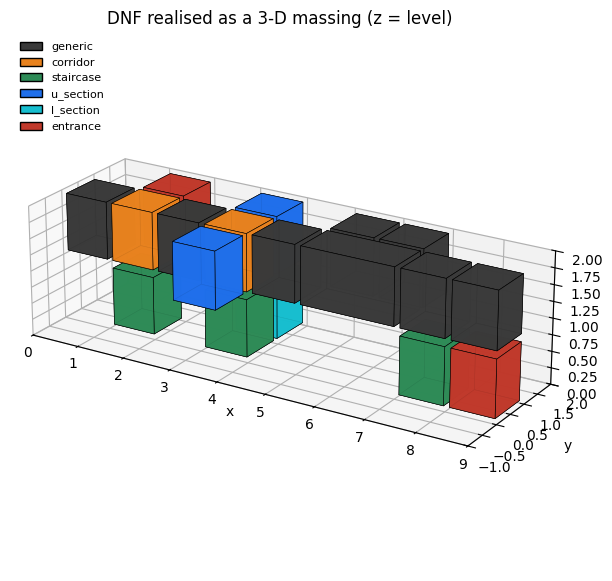

In [29]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
topoview.draw_massing(G, ax=ax)
ax.legend(handles=topoview.legend_handles(), loc="upper left", fontsize=8, frameon=False)
ax.set_title("DNF realised as a 3-D massing (z = level)")
None

### The geometric matcher (§9) — congruence replaces the combinatorial predicate

At Stage 2 a rule can match by *shape*: `IsSimilar` finds cells congruent to a query.
Here, querying a staircase shape returns the staircases (and corridors, which are the
same 2×1×1 congruence class) — and never the unit-cube generics.

In [30]:
cells = realise.typed_cells(G)
q = realise.typed_cell(A.STAIRCASE)
sim = realise.find_similar(q, cells)
from collections import Counter
print("cells congruent to a staircase shape:", dict(Counter(G.node_label(n) for n in sim)))
print("box ~ box      :", realise.is_similar(realise.typed_cell(A.GENERIC), realise.typed_cell(A.GENERIC)))
print("box ~ staircase:", realise.is_similar(realise.typed_cell(A.GENERIC), realise.typed_cell(A.STAIRCASE)))

cells congruent to a staircase shape: {'corridor': 2, 'staircase': 3}
box ~ box      : True


box ~ staircase: False


## Stage 2 — geometry refinements (a → b → c)

**(a) true U/L section profiles** — U and L are real extruded profile solids (not
boxes), so the geometric matcher can finally tell them apart. **(b) constraint
repair** — variable-size cells (a spanning L under two U's; a 3-rectangle pinwheel
for H-triangles) realise the grid-unfriendly motifs, with every repair guarded so
it can only *increase* coverage. **(c) geometric matching in the rule engine** —
the same productions match by *shape* when given `realise.shape_matcher`.

In [31]:
# (a) the section profiles are genuine solids, and U ≇ L geometrically
for lab in [A.U_SECTION, A.L_SECTION]:
    c = realise.typed_cell(lab)
    from topologicpy.Cell import Cell
    print(f"  {lab:<10} faces={len(Cell.Faces(c))}  volume={Cell.Volume(c):.2f}")
print("U ~ U :", realise.is_similar(realise.typed_cell(A.U_SECTION), realise.typed_cell(A.U_SECTION)))
print("U ~ L :", realise.is_similar(realise.typed_cell(A.U_SECTION), realise.typed_cell(A.L_SECTION)),
      "  (boxes never distinguished these)")

  u_section  faces=10  volume=1.44
  l_section  faces=8  volume=1.35
U ~ U : True
U ~ L : False   (boxes never distinguished these)


In [32]:
# (b) the two hard motifs round-trip exactly in isolation; the DNF improves to 17/18
def cov(g):
    r = realise.roundtrip_report(g); return f"{len(r['realised'])}/{len(r['realised'])+len(r['unrealised'])} complete={r['complete']}"

tri = StateGraph()
for i in "abc": tri.add_node(A.GENERIC, id=i)
tri.add_edge("a","b",A.H); tri.add_edge("b","c",A.H); tri.add_edge("a","c",A.H)
il = StateGraph()
il.add_node(A.U_SECTION,id="u1"); il.add_node(A.U_SECTION,id="u2"); il.add_node(A.L_SECTION,id="l")
il.add_edge("u1","u2",A.H); il.add_edge("u1","l",A.V); il.add_edge("u2","l",A.V)
print("toilet 3-cycle (clique repair):", cov(tri))
print("U/L interlock  (span repair)  :", cov(il))
print("full DNF                      :", cov(dnf.derive_dnf()[0]))

toilet 3-cycle (clique repair): 3/3 complete=True


U/L interlock  (span repair)  : 3/3 complete=True


full DNF                      : 17/18 complete=True


In [33]:
# (c) same productions, geometric predicate — matching by shape, not label
from graphtope.rules import Pattern, PNode, match_pattern
from collections import Counter
gm = realise.shape_matcher(G)
pat = Pattern([PNode("s", label=A.STAIRCASE)])
combo = {m["s"] for m in match_pattern(pat, G)}
geo   = {m["s"] for m in match_pattern(pat, G, node_matcher=gm)}
print("staircase pattern, combinatorial:", dict(Counter(G.node_label(n) for n in combo)))
print("staircase pattern, geometric    :", dict(Counter(G.node_label(n) for n in geo)),
      " <- staircase & corridor are the same shape class")
patu = Pattern([PNode("u", label=A.U_SECTION)])
geou = {m["u"] for m in match_pattern(patu, G, node_matcher=gm)}
print("u_section pattern, geometric    :", dict(Counter(G.node_label(n) for n in geou)),
      " <- profiles separate U from L")

staircase pattern, combinatorial: {'staircase': 3}
staircase pattern, geometric    : {'staircase': 3, 'corridor': 2}  <- staircase & corridor are the same shape class


u_section pattern, geometric    : {'u_section': 2}  <- profiles separate U from L


## Stage 2 status

The bridge is complete end-to-end: τ realises nodes as Topologic Cells (boxes +
true U/L section profiles); a deterministic, constraint-repaired layout turns
adjacencies into shared faces (**17/18** on the full DNF, **100%** on grid-embeddable
configs and on the isolated hard motifs); `CellComplex` + `Graph.ByTopology`
round-trip the adjacency back; and `IsSimilar` provides the geometric match
predicate — pluggable into the rule engine **without changing the rule structure**
(§9). The last DNF adjacency (one U/L interlock the greedy layout boxes a staircase
into) needs a global floor-planner — the honest remaining limit.